In [33]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [6]:
with open("../data/normas/metadados/normas.json", "r", encoding="utf-8") as f:
    normas = json.load(f)

with open("../data/senado/metadados/proposicoes.json", "r", encoding="utf-8") as f:
    normas = json.load(f)

In [25]:
normas_df = pd.read_parquet("../data/datasets/normas.parquet")
proposicoes_df = pd.read_parquet("../data/datasets/proposicoes.parquet")
emendas_df = pd.read_parquet("../data/datasets/emendas.parquet")

In [9]:
print("Total de normas coletadas (2010 - 2025):", len(normas))

Total de normas coletadas (2010 - 2025): 9508


In [22]:
print("Total de normas com proposições de origem (2010 - 2025):", len(normas_df))

Total de normas com proposições de origem (2010 - 2025): 9498


In [27]:
normas_com_emendas = (
    proposicoes_df[
        proposicoes_df["id"].isin(emendas_df["id_proposicao"])
    ]["urn_norma"]
    .nunique()
)

print("Normas com pelo menos 1 emenda durante sua tramitação", normas_com_emendas)

Normas com pelo menos 1 emenda durante sua tramitação 1948


In [28]:
emendas_por_norma = (
    proposicoes_df[
        proposicoes_df["id"].isin(emendas_df["id_proposicao"])
    ]
    .merge(
        emendas_df[["id_proposicao"]],
        left_on="id",
        right_on="id_proposicao",
        how="inner",
    )
    .groupby("urn_norma")
    .size()
)

emendas_por_norma = emendas_por_norma[emendas_por_norma > 0]

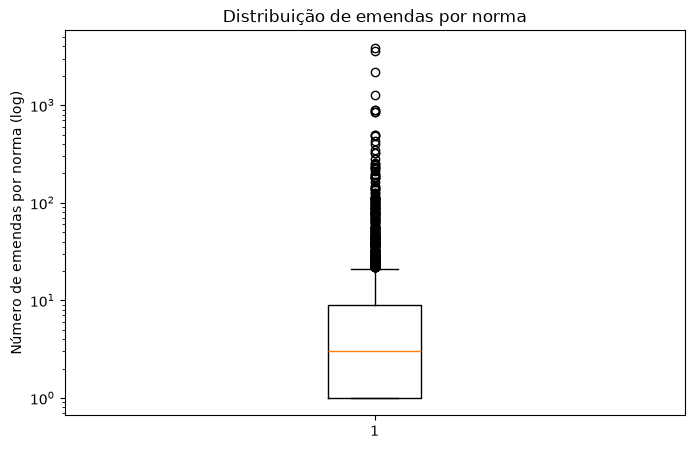

In [35]:
plt.figure(figsize=(8, 5))

plt.boxplot(emendas_por_norma)
plt.yscale("log")

plt.ylabel("Número de emendas por norma (log)")
plt.title("Distribuição de emendas por norma")

plt.show()